#### Experiment 1
- 1D
- Linear variation - electrode exponenets vary from -1 to -2
- 5 electrodes
- Aperiodic noise only
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [2]:
# Imports for functionality 
from dissertation_simulations.time_series import sweep_electrodes_ts_2D
from dissertation_simulations.psd import sweep_electrodes_psd_2D
from dissertation_simulations.spec_mod import sweep_electrodes_specmod_2D
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.plotting import plot_summary_boxplots

import numpy as np
import json

from scipy.stats import ttest_rel

In [2]:
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")
exp_matrix

array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]])

In [4]:
# Average the time series
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")

electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_ts_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1_result1_ts = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results1_ts_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1_result1_ts, f, indent=4)

In [5]:
# Average the PSD
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")

electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1_result2_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results2_psd_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1_result2_psd, f, indent=4)

In [6]:
# Average the SpecMod
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")

electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results3_specmod_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1_result3_specmod, f, indent=4)

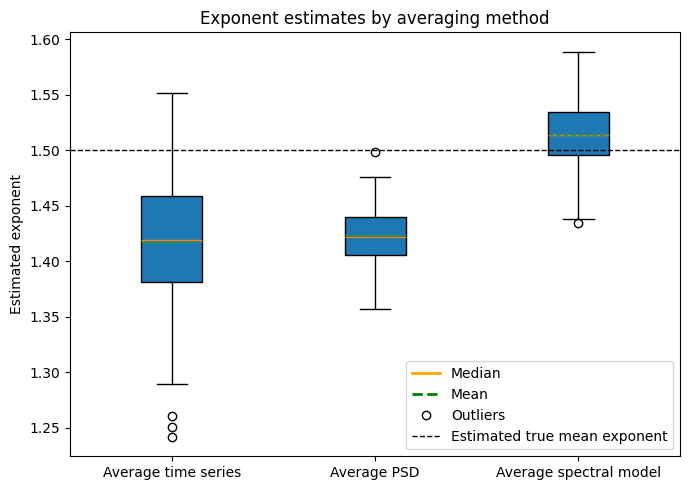

In [7]:
# Loading summaries and combining into a single plot

summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results1_ts_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results2_psd_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1results3_specmod_exp_matrix_cols_-1-2.json"
]

labels = [
    "Average time series",
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp1_combined_plot_1D_exp_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")

In [10]:
# Paired t-tests
with open(summary_paths[0]) as f:
    ts_data = json.load(f)

with open(summary_paths[1]) as f:
    psd_data = json.load(f)

with open(summary_paths[2]) as f:
    spec_data = json.load(f)

ts = np.array(ts_data["all_distributions"][0])
psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(ts, psd)
print(f"Time series vs PSD: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(ts, spec)
print(f"Time series vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

Time series vs PSD: t = -0.906, p = 0.36722
Time series vs Spectral model: t = -13.899, p = 0.00000
PSD vs Spectral model: t = -24.734, p = 0.00000


#### Experiment 1b
- Sanity check
- Same as experiment above but matrix values are defined the other way around
- Should produce a similar plot to above

In [8]:
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-1, -2), gradient_axis="cols")
exp_matrix

array([[-1.  , -1.25, -1.5 , -1.75, -2.  ]])

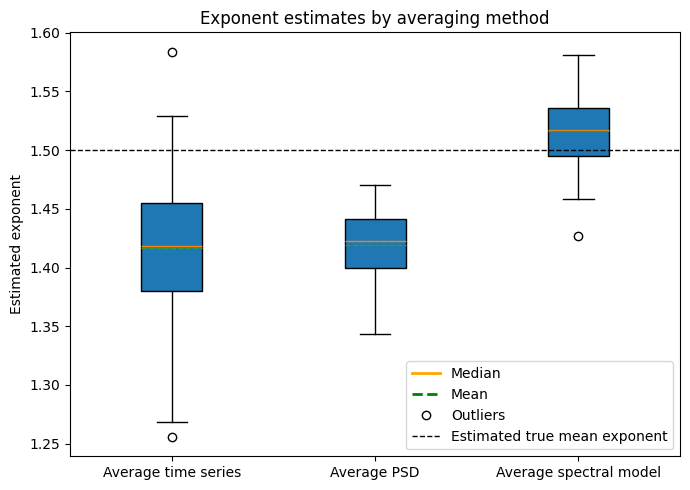

In [10]:
# Define electrode matrix
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-1, -2), gradient_axis="cols")

# Average the time series
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_ts_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1b_result1_ts = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults1_ts_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1b_result1_ts, f, indent=4)

# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1b_result2_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults2_psd_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1b_result2_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1b_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults3_specmod_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1b_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults1_ts_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults2_psd_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults3_specmod_exp_matrix_cols_-1-2.json"
]

labels = [
    "Average time series",
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp1b_combined_plot_1D_exp_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")